In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from sklearn.metrics import silhouette_score

In [33]:
df = pd.read_csv("Credit_card_dataset.csv")

In [34]:
df.head()

,CUST_ID,BALANCE_FREQUENCY,PURCHASES,PAYMENTS,CREDIT_LIMIT,CASH_ADVANCE
0,C10001,0.818182,95.40,201.802084,1000.0,0.000000
1,C10002,0.909091,0.00,4103.032597,7000.0,6442.945483
2,C10003,1.000000,773.17,622.066742,7500.0,0.000000
3,C10004,0.636364,1499.00,0.000000,7500.0,205.788017
4,C10005,1.000000,16.00,678.334763,1200.0,0.000000


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CUST_ID            8950 non-null   object 
 1   BALANCE_FREQUENCY  8950 non-null   float64
 2   PURCHASES          8950 non-null   float64
 3   PAYMENTS           8950 non-null   float64
 4   CREDIT_LIMIT       8949 non-null   float64
 5   CASH_ADVANCE       8950 non-null   float64
dtypes: float64(5), object(1)
memory usage: 419.7+ KB


In [36]:
df = df.dropna()

In [37]:
features = ['PURCHASES', 'CREDIT_LIMIT']
X = df[features]

In [38]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

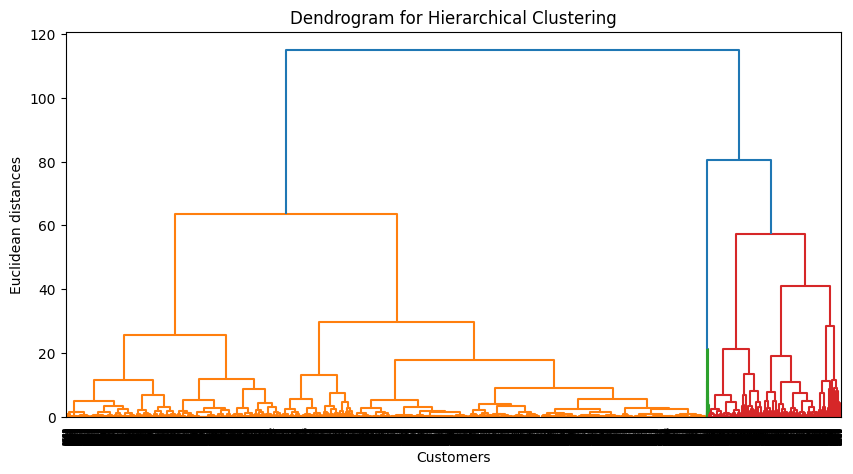

In [39]:
plt.figure(figsize=(10, 5))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Customers")
plt.ylabel("Euclidean distances")
plt.show()

In [40]:
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df['Cluster_HC'] = hc.fit_predict(X_scaled)

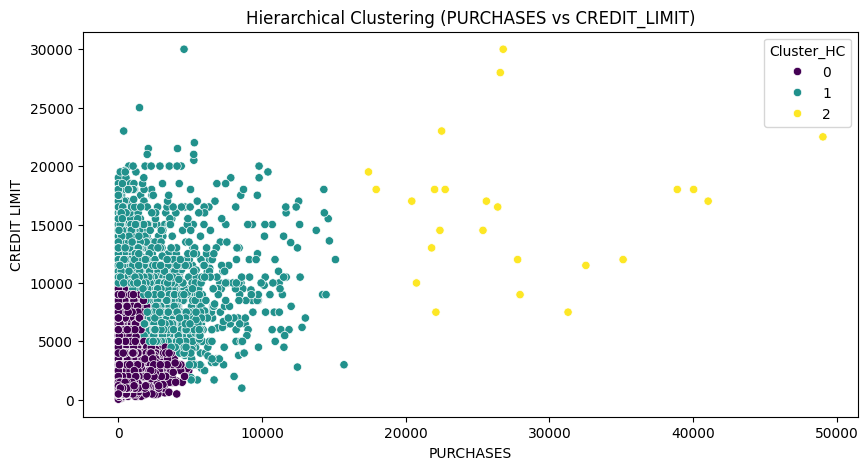

In [41]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df['PURCHASES'], y=df['CREDIT_LIMIT'], hue=df['Cluster_HC'], palette="viridis")
plt.title("Hierarchical Clustering (PURCHASES vs CREDIT_LIMIT)")
plt.xlabel("PURCHASES")
plt.ylabel("CREDIT LIMIT")
plt.show()

In [43]:
inertia_errors = []
n_clusters = range(2, 11)
silhouette_scores = []

for k in n_clusters:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia_errors.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, model.labels_))

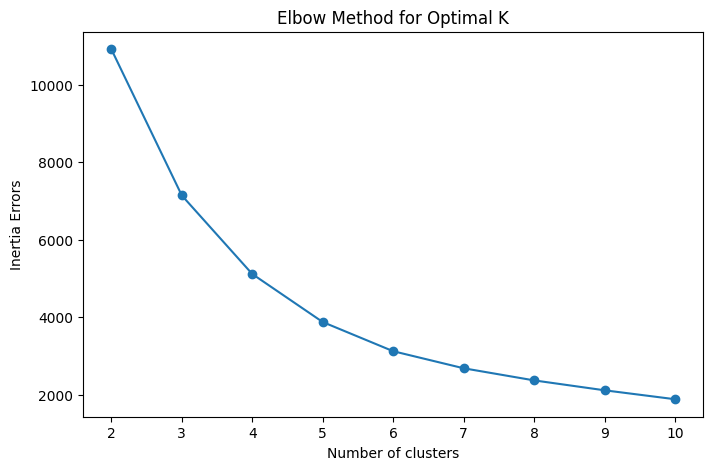

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(n_clusters, inertia_errors, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia Errors")
plt.show()

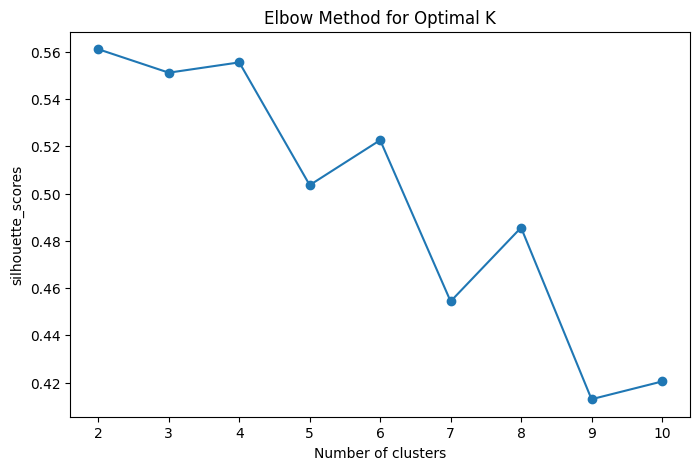

In [45]:
plt.figure(figsize=(8, 5))
plt.plot(n_clusters, silhouette_scores, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of clusters")
plt.ylabel("silhouette_scores")
plt.show()

In [46]:
optimal_k = 6
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

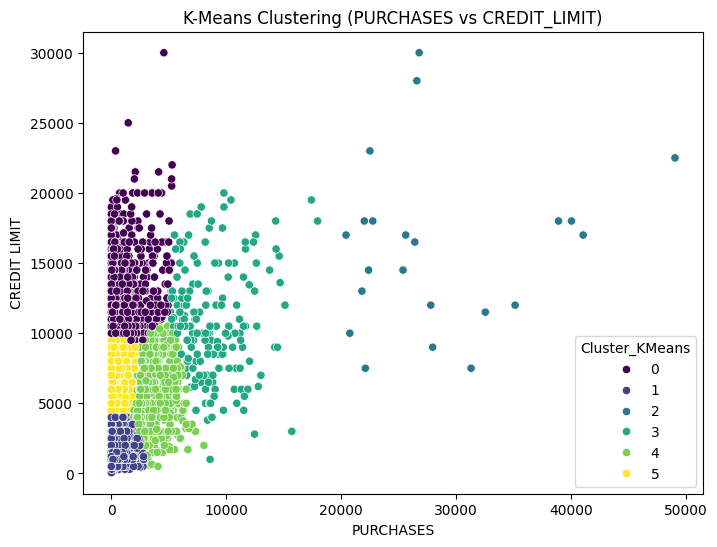

In [47]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['PURCHASES'], y=df['CREDIT_LIMIT'], hue=df['Cluster_KMeans'], palette="viridis")
plt.title("K-Means Clustering (PURCHASES vs CREDIT_LIMIT)")
plt.xlabel("PURCHASES")
plt.ylabel("CREDIT LIMIT")
plt.show()

In [48]:
cluster_counts = df['Cluster_KMeans'].value_counts()
print("Cluster Distribution:\n", cluster_counts)

Cluster Distribution:
 Cluster_KMeans
1    5145
5    2098
4     781
0     733
3     170
2      22
Name: count, dtype: int64
